In [3]:
# ── Calcular pesos por muestra para manejar desbalanceo ──
import cupy as cp
n_total   = len(y_train)
n_fuego   = int((y_train == 1).sum())
n_no_fuego= int((y_train == 0).sum())

peso_fuego    = n_total / (2 * n_fuego)
peso_no_fuego = n_total / (2 * n_no_fuego)

# Vector de pesos para cuML
pesos_gpu = y_train.map({0: peso_no_fuego, 1: peso_fuego}).astype("float32")

# Vector de pesos para sklearn
pesos_cpu = y_train.to_pandas().map({0: peso_no_fuego, 1: peso_fuego}).values

print(f"Peso clase 0 (sin incendio): {peso_no_fuego:.4f}")
print(f"Peso clase 1 (con incendio): {peso_fuego:.4f}")

# ── BENCHMARK CPU vs GPU ──
# ── Manejar desbalanceo con oversampling manual ──
# Duplicar los registros con incendio hasta tener relación 1:5
print("Aplicando oversampling a clase minoritaria...")

X_train_pd = X_train.to_pandas()
y_train_pd = y_train.to_pandas()

train_df = X_train_pd.copy()
train_df["fuego"] = y_train_pd.values

fuego_df    = train_df[train_df["fuego"] == 1]
no_fuego_df = train_df[train_df["fuego"] == 0]

# Repetir los incendios hasta tener 1:5
repeticiones = max(1, len(no_fuego_df) // (len(fuego_df) * 5))
fuego_over   = pd.concat([fuego_df] * repeticiones, ignore_index=True)
train_bal    = pd.concat([no_fuego_df, fuego_over]).sample(
    frac=1, random_state=42).reset_index(drop=True)

X_train_bal = train_bal[FEATURES].values.astype("float32")
y_train_bal = train_bal["fuego"].values.astype("int32")

print(f"Train balanceado: {train_bal.shape}")
print(f"Distribucion:\n{train_bal['fuego'].value_counts()}")

# Pasar a cuDF para GPU
import cudf as cd
X_train_gpu = cd.DataFrame.from_pandas(
    pd.DataFrame(X_train_bal, columns=FEATURES))
y_train_gpu = cd.Series(y_train_bal)

# ── BENCHMARK CPU vs GPU ──
print("\n" + "="*55)
print("BENCHMARK: Random Forest CPU vs GPU")
print("="*55)

configs    = [10, 50, 100, 200, 500]
resultados = []

for n_trees in configs:
    # GPU — cuML
    t0 = time.perf_counter()
    rf_gpu = cuRF(n_estimators=n_trees, max_depth=12, random_state=42)
    rf_gpu.fit(X_train_gpu, y_train_gpu)
    pred_gpu = rf_gpu.predict(X_test).to_pandas().values
    t_gpu = time.perf_counter() - t0
    f1_gpu  = f1_score(y_test_np, pred_gpu)
    auc_gpu = roc_auc_score(y_test_np, pred_gpu)

    # CPU — sklearn
    t0 = time.perf_counter()
    rf_cpu = skRF(n_estimators=n_trees, max_depth=12,
                  n_jobs=-1, random_state=42)
    rf_cpu.fit(X_train_bal, y_train_bal)
    pred_cpu = rf_cpu.predict(X_test_np)
    t_cpu = time.perf_counter() - t0
    f1_cpu  = f1_score(y_test_np, pred_cpu)
    auc_cpu = roc_auc_score(y_test_np, pred_cpu)

    speedup = t_cpu / t_gpu

    resultados.append({
        "n_estimators": n_trees,
        "tiempo_gpu_s": round(t_gpu, 2),
        "tiempo_cpu_s": round(t_cpu, 2),
        "speedup":      round(speedup, 2),
        "f1_gpu":       round(f1_gpu, 4),
        "f1_cpu":       round(f1_cpu, 4),
        "auc_gpu":      round(auc_gpu, 4),
        "auc_cpu":      round(auc_cpu, 4),
    })
    print(f"  {n_trees:>3} árboles → "
          f"GPU: {t_gpu:6.2f}s | CPU: {t_cpu:6.2f}s | "
          f"Speedup: {speedup:.1f}x | F1-GPU: {f1_gpu:.4f}")

df_bench = pd.DataFrame(resultados)
df_bench.to_csv("/home/ulead-20/data_gee/benchmark_cpu_vs_gpu.csv", index=False)
print("\nBenchmark guardado.")
print(df_bench.to_string(index=False))

Peso clase 0 (sin incendio): 0.5500
Peso clase 1 (con incendio): 5.5000
Aplicando oversampling a clase minoritaria...
Train balanceado: (904341, 9)
Distribucion:
fuego
0    822128
1     82213
Name: count, dtype: int64

BENCHMARK: Random Forest CPU vs GPU
   10 árboles → GPU:   3.42s | CPU:   4.58s | Speedup: 1.3x | F1-GPU: 0.3578
   50 árboles → GPU:   1.76s | CPU:  16.14s | Speedup: 9.2x | F1-GPU: 0.3517
  100 árboles → GPU:   3.72s | CPU:  31.14s | Speedup: 8.4x | F1-GPU: 0.3515
  200 árboles → GPU:   7.65s | CPU:  63.35s | Speedup: 8.3x | F1-GPU: 0.3510
  500 árboles → GPU:  18.97s | CPU: 156.62s | Speedup: 8.3x | F1-GPU: 0.3503

Benchmark guardado.
 n_estimators  tiempo_gpu_s  tiempo_cpu_s  speedup  f1_gpu  f1_cpu  auc_gpu  auc_cpu
           10          3.42          4.58     1.34  0.3578  0.3806   0.6147   0.6247
           50          1.76         16.14     9.18  0.3517  0.3759   0.6120   0.6223
          100          3.72         31.14     8.38  0.3515  0.3765   0.6118   0.6225

Reporte final — 500 árboles, GPU V100
              precision    recall  f1-score   support

Sin incendio       0.93      0.99      0.96    205532
Con incendio       0.72      0.23      0.35     20553

    accuracy                           0.92    226085
   macro avg       0.82      0.61      0.65    226085
weighted avg       0.91      0.92      0.90    226085



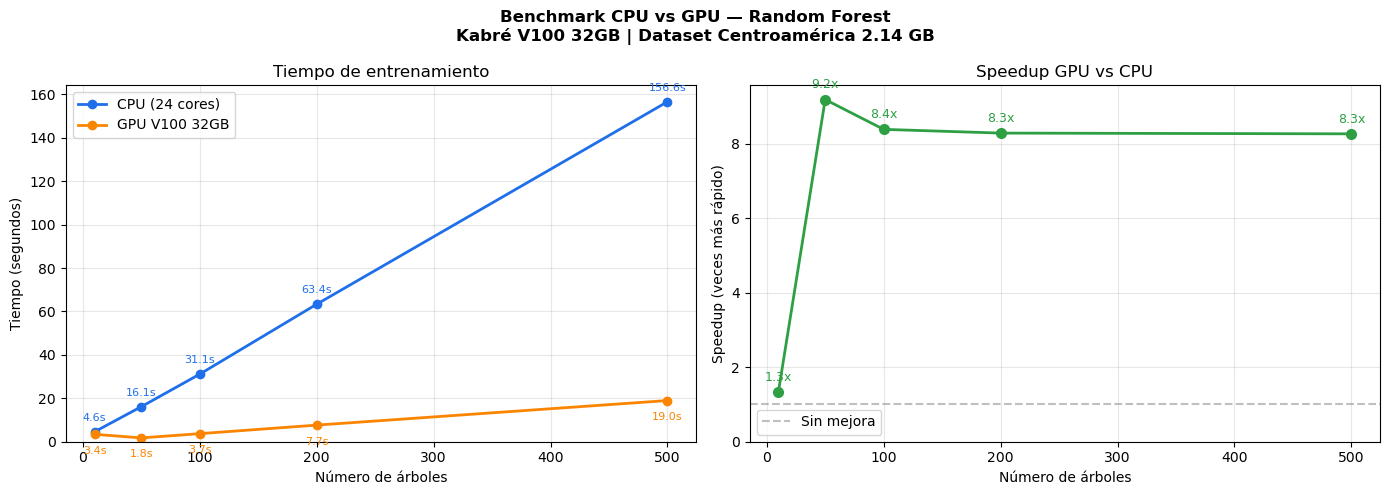

Gráfica guardada.


In [4]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# ── Reporte del mejor modelo (500 árboles GPU) ──
print("="*55)
print("Reporte final — 500 árboles, GPU V100")
print("="*55)
print(classification_report(y_test_np, pred_gpu,
      target_names=["Sin incendio", "Con incendio"]))

# ── Gráficas ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Benchmark CPU vs GPU — Random Forest\n"
    "Kabré V100 32GB | Dataset Centroamérica 2.14 GB",
    fontsize=12, fontweight="bold")

# Panel 1: Tiempo
ax1.plot(df_bench["n_estimators"], df_bench["tiempo_cpu_s"],
         "-o", label="CPU (24 cores)", color="#1f6feb", linewidth=2)
ax1.plot(df_bench["n_estimators"], df_bench["tiempo_gpu_s"],
         "-o", label="GPU V100 32GB", color="#fb8500", linewidth=2)
for x, yc, yg in zip(df_bench["n_estimators"],
                      df_bench["tiempo_cpu_s"],
                      df_bench["tiempo_gpu_s"]):
    ax1.annotate(f"{yc:.1f}s", (x, yc), textcoords="offset points",
                 xytext=(0, 8), ha="center", fontsize=8, color="#1f6feb")
    ax1.annotate(f"{yg:.1f}s", (x, yg), textcoords="offset points",
                 xytext=(0, -14), ha="center", fontsize=8, color="#fb8500")
ax1.set_xlabel("Número de árboles")
ax1.set_ylabel("Tiempo (segundos)")
ax1.set_title("Tiempo de entrenamiento")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# Panel 2: Speedup
ax2.plot(df_bench["n_estimators"], df_bench["speedup"],
         "-o", color="#2ea043", linewidth=2, markersize=7)
ax2.axhline(y=1, color="gray", linestyle="--", alpha=0.5, label="Sin mejora")
for x, s in zip(df_bench["n_estimators"], df_bench["speedup"]):
    ax2.annotate(f"{s:.1f}x", (x, s), textcoords="offset points",
                 xytext=(0, 8), ha="center", fontsize=9, color="#2ea043")
ax2.set_xlabel("Número de árboles")
ax2.set_ylabel("Speedup (veces más rápido)")
ax2.set_title("Speedup GPU vs CPU")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("/home/ulead-20/data_gee/benchmark_speedup_kabre.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada.")

In [ ]:
import folium
from folium.plugins import HeatMap
import pandas as pd
import cudf as cd
import numpy as np

# ── Cargar grilla de Centroamérica para inferencia ──
# Usamos el dataset limpio pero tomamos solo las coordenadas únicas
# y les asignamos condiciones de época seca para el escenario
print("Generando grilla de inferencia...")

# Tomar una muestra representativa del dataset para la grilla
df_grilla = df[FEATURES + ["longitude", "latitude"]].to_pandas()

# Definir escenario: condiciones típicas de época seca en Guanacaste
# (marzo, temperatura alta, sin lluvia, viento moderado)
ESCENARIO = {
    "temperatura":   305.0,   # ~32°C en Kelvin
    "precipitacion": 0.001,   # casi sin lluvia
    "viento_u":      3.5,
    "viento_v":      1.2,
}

# Aplicar condiciones del escenario
df_escenario = df_grilla.copy()
for col, val in ESCENARIO.items():
    df_escenario[col] = val

# Predecir probabilidad de incendio
X_grilla = cd.DataFrame.from_pandas(
    df_escenario[FEATURES].astype("float32"))
probs = rf_gpu.predict_proba(X_grilla)

if hasattr(probs, "to_pandas"):
    probs_np = probs.to_pandas().iloc[:, 1].values
else:
    probs_np = probs[:, 1]

df_escenario["prob_incendio"] = probs_np

# Filtrar probabilidades significativas para el heatmap
df_heat = df_escenario[df_escenario["prob_incendio"] > 0.1]
print(f"Puntos para heatmap: {len(df_heat):,}")
print(f"Prob máxima: {df_heat['prob_incendio'].max():.4f}")

# ── Crear mapa de calor con Folium ──
mapa = folium.Map(
    location=[10.5, -84.5],
    zoom_start=6,
    tiles="CartoDB positron"
)

# Heatmap de riesgo
heat_data = df_heat[["latitude", "longitude", "prob_incendio"]].values.tolist()
HeatMap(
    heat_data,
    min_opacity=0.3,
    radius=10,
    blur=8,
    gradient={
        0.2: "blue",
        0.4: "cyan",
        0.6: "yellow",
        0.8: "orange",
        1.0: "red"
    }
).add_to(mapa)

# Agregar título
titulo = """
<div style="position: fixed; top: 10px; left: 50px; z-index: 1000;
     background-color: white; padding: 10px; border-radius: 8px;
     border: 2px solid #ccc; font-family: Arial;">
    <b>Mapa de Riesgo de Incendio — Centroamérica</b><br>
    Escenario: Época seca | T°: 32°C | Sin lluvia<br>
    Modelo: Random Forest GPU (V100) | Dataset: 2.14 GB
</div>
"""
mapa.get_root().html.add_child(folium.Element(titulo))

folium.LayerControl().add_to(mapa)
mapa.save("/home/ulead-20/data_gee/mapa_riesgo_centroamerica.html")
print("Mapa guardado en data_gee/mapa_riesgo_centroamerica.html")
mapa

Generando grilla de inferencia...
Puntos para heatmap: 10,640,970
Prob máxima: 0.5779
